# Notebook 02 — CIR Model Calibration

---

## Purpose

This notebook calibrates the Cox-Ingersoll-Ross (CIR) short-rate model on historical 3-Month Treasury yield data.

**Why short-rate modelling matters:**  
Interest rates are the discounting backbone of all fixed-income instruments. A well-calibrated short-rate model lets us simulate future rate paths, derive bond prices analytically, and reconstruct an entire yield curve from a single observable input.

**CIR dynamics:**

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Meaning |
|-----------|---------|
| $\kappa$ | Speed of mean reversion |
| $\theta$ | Long-run mean of the short rate |
| $\sigma$ | Volatility coefficient |

**Objective:**  
Estimate $(\kappa, \theta, \sigma)$ from `cleaned_train.csv`, validate the calibration, and export the parameters to `results/cir_parameters.csv` for Notebook 03.


## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy.optimize import minimize, OptimizeResult
from scipy.stats import jarque_bera, probplot
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROC_DIR    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR     = RESULTS_DIR / "figures"
PARAM_FILE = RESULTS_DIR / "cir_parameters.csv"

for d in [RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports successful.")
print(f"Results will be written to: {RESULTS_DIR}")

All imports successful.
Results will be written to: /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results


## 2. Load Cleaned Data

Load `cleaned_train.csv` and extract the **3M yield** as the short-rate proxy $r_t$.


In [2]:
def load_short_rate(
    path: Path,
    tenor: str = "3M"
) -> Tuple[pd.Series, pd.DataFrame]:
    """
Load cleaned Treasury yield data and extract the chosen short-rate proxy.

Parameters
----------
path : Path
    Path to cleaned dataset.
tenor : str
    Treasury maturity used as short rate.

Returns
-------
r : pd.Series
    Selected short-rate series.
df : pd.DataFrame
    Full cleaned dataset.
"""

    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if tenor not in df.columns:
        raise KeyError(f"Column '{tenor}' not found. Available: {list(df.columns)}")

    r = df[tenor].dropna()
    return r, df


short_rate, df_train = load_short_rate(PROC_DIR / "cleaned_train.csv", tenor="3M")

print(f"Training observations : {len(short_rate)}")
print(f"Date range            : {short_rate.index[0].date()} -> {short_rate.index[-1].date()}")
print()
print("Summary statistics (3M yield):")
print(short_rate.describe().round(4).to_string())
print(f"\nNegative observations : {(short_rate < 0).sum()}")


Training observations : 1976
Date range            : 2016-05-19 -> 2024-04-26

Summary statistics (3M yield):
count    1976.0000
mean        0.0167
std         0.0166
min         0.0005
25%         0.0046
50%         0.0119
75%         0.0171
max         0.0520

Negative observations : 0


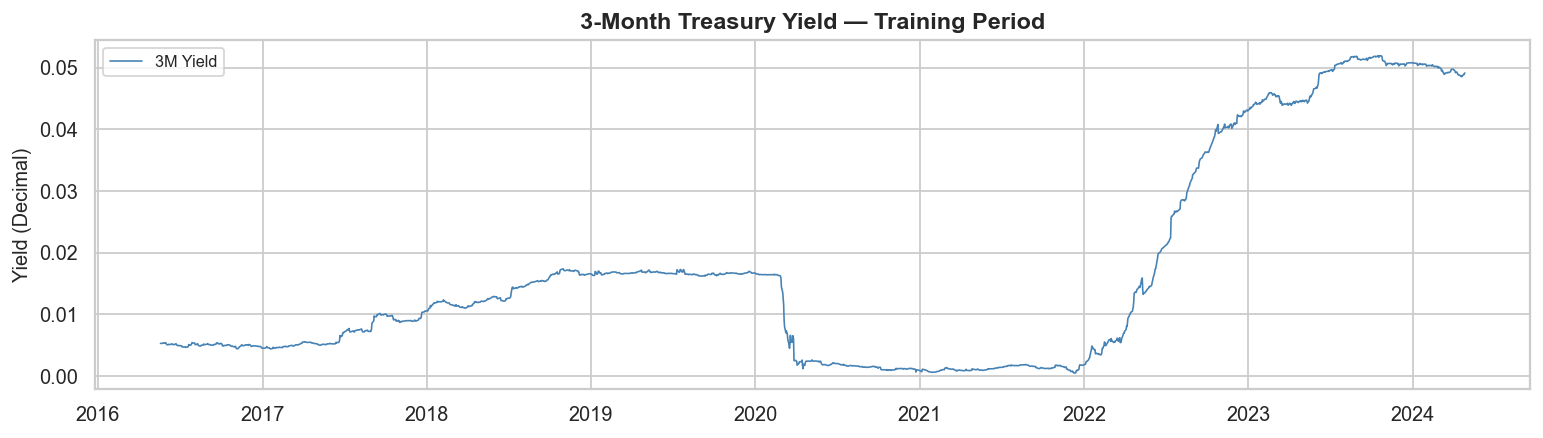

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(short_rate.index, short_rate.values, lw=0.9, color="steelblue", label="3M Yield")
ax.set_title("3-Month Treasury Yield — Training Period")
ax.set_ylabel("Yield (Decimal)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "short_rate_series.png", dpi=130, bbox_inches="tight")
plt.show()


## 3. Short-Rate Diagnostics for Calibration Method Selection

Before choosing an estimator, we evaluate four properties that directly determine which calibration framework is most appropriate.

| Diagnostic | Why it matters |
|-----------|----------------|
| Sampling frequency | Determines $\Delta t$; affects discretisation error |
| Distributional shape | Informs whether Gaussian-innovation assumptions hold |
| Autocorrelation | High persistence → large $1/\kappa$; convergence sensitivity |
| Frequency of non-positive values | CIR requires $r_t > 0$; negatives are a structural mismatch |


In [4]:
from scipy.stats import skew, kurtosis as kurt

# ── 3.1  Sampling frequency ───────────────────────────────────────────────
gaps    = short_rate.index.to_series().diff().dt.days.dropna()
dt_med  = gaps.median() / 365.0

print("── Sampling Frequency ──────────────────────────────────────────")
print(f"  Median gap (calendar days) : {gaps.median():.0f}")
print(f"  Delta-t in years           : {dt_med:.6f}")
print(f"  Approx frequency           : {'Daily' if gaps.median() <= 1 else 'Weekly' if gaps.median() <= 7 else 'Monthly'}")

# ── 3.2  Distribution ─────────────────────────────────────────────────────
r_vals     = short_rate.values
jb_s, jb_p = jarque_bera(r_vals)

print("\n── Distribution ────────────────────────────────────────────────")
print(f"  Mean      : {np.mean(r_vals):.4f}")
print(f"  Std       : {np.std(r_vals):.4f}")
print(f"  Skewness  : {skew(r_vals):.4f}")
print(f"  Ex. Kurt  : {kurt(r_vals):.4f}")
print(f"  JB stat   : {jb_s:.2f}  (p = {jb_p:.4f})")

# ── 3.3  Autocorrelation ──────────────────────────────────────────────────
acf_vals = acf(r_vals, nlags=5, fft=True)
lag1_corr = pd.Series(r_vals).autocorr(lag=1)

print("\n── Autocorrelation ─────────────────────────────────────────────")
print(f"  Lag-1 persistence : {lag1_corr:.4f}")
if lag1_corr > 0.95:
    print("  Very high persistence detected")
for lag, val in enumerate(acf_vals[1:], 1):
    print(f"  ACF lag {lag} : {val:.4f}")

# ── 3.4  Positivity ───────────────────────────────────────────────────────
n_neg  = (short_rate < 0).sum()
pct_neg = n_neg / len(short_rate) * 100
print("\n── Positivity ──────────────────────────────────────────────────")
print(f"  Obs with r_t < 0 : {n_neg} ({pct_neg:.2f} %)")
if n_neg > 0:
    print(f"  Min yield        : {short_rate.min():.4f}")
    print("  Warning: negative yields present — CIR strict positivity violated in-sample.")
else:
    print("  All observations positive — CIR assumption holds in-sample.")

near_zero = (short_rate < 0.0025).sum()
print(f"  Obs with r_t < 0.25% : {near_zero}")

print("\n── Method Selection Signals ───────────────────────────────────")
print("- Large sample size available")
print("- High-frequency observations")
print("- Strong persistence in short rates")
if n_neg == 0:
    print("- No negative rates observed")
else:
    print("- Negative rates present")
print("- Near-zero rate episodes present")


── Sampling Frequency ──────────────────────────────────────────
  Median gap (calendar days) : 1
  Delta-t in years           : 0.002740
  Approx frequency           : Daily

── Distribution ────────────────────────────────────────────────
  Mean      : 0.0167
  Std       : 0.0166
  Skewness  : 1.0642
  Ex. Kurt  : -0.2905
  JB stat   : 379.92  (p = 0.0000)

── Autocorrelation ─────────────────────────────────────────────
  Lag-1 persistence : 0.9999
  Very high persistence detected
  ACF lag 1 : 0.9988
  ACF lag 2 : 0.9976
  ACF lag 3 : 0.9964
  ACF lag 4 : 0.9951
  ACF lag 5 : 0.9938

── Positivity ──────────────────────────────────────────────────
  Obs with r_t < 0 : 0 (0.00 %)
  All observations positive — CIR assumption holds in-sample.
  Obs with r_t < 0.25% : 435

── Method Selection Signals ───────────────────────────────────
- Large sample size available
- High-frequency observations
- Strong persistence in short rates
- No negative rates observed
- Near-zero rate episodes p

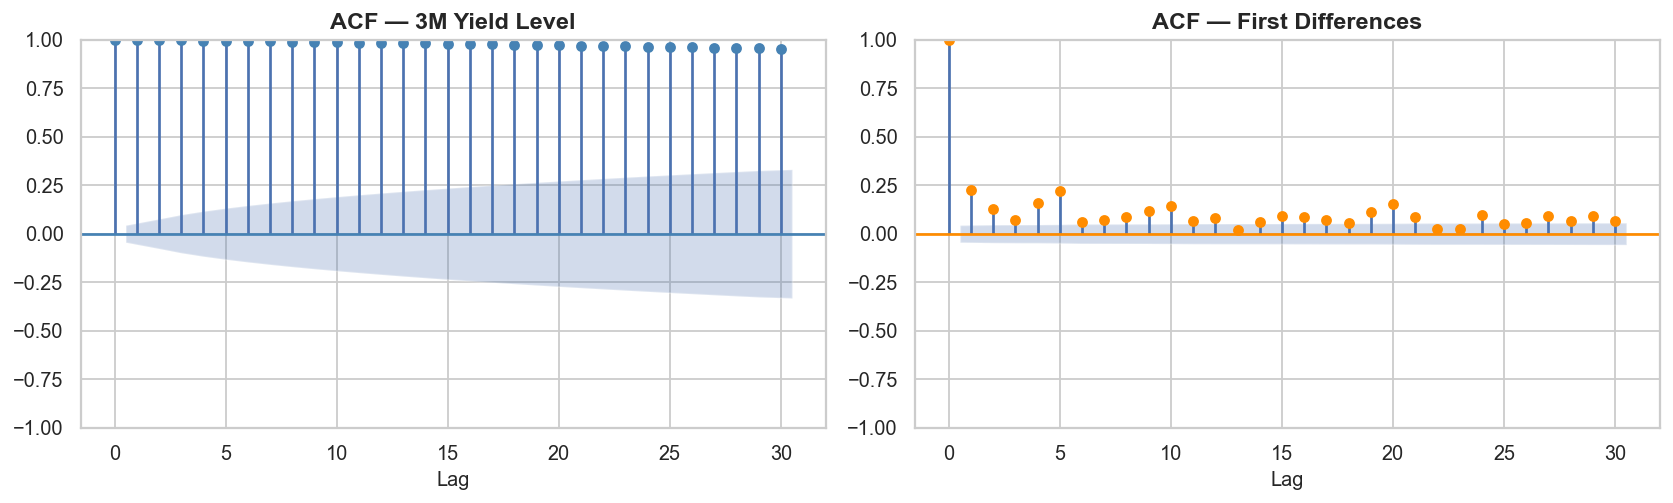

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(r_vals, lags=30, ax=axes[0], alpha=0.05,
         color="steelblue", title="ACF — 3M Yield Level")

plot_acf(np.diff(r_vals), lags=30, ax=axes[1], alpha=0.05,
         color="darkorange", title="ACF — First Differences")

for ax in axes:
    ax.set_xlabel("Lag")

plt.tight_layout()
plt.savefig(FIG_DIR / "acf_short_rate.png", dpi=130, bbox_inches="tight")
plt.show()


### Method Selection: QMLE

**Comparison of candidate methods:**

| Method | Assumptions | Complexity | Robustness |
|--------|-------------|------------|------------|
| OLS (discretised) | Gaussian increments, constant variance | Very low | Poor — CIR variance scales with $r_t$; heteroskedasticity biases OLS |
| **QMLE** | Correct conditional mean & variance; Gaussian quasi-likelihood | Low-Medium | **Good** — consistent under mild regularity; robust to non-Gaussianity |
| Exact MLE (ncx2) | Full non-central $\chi^2$ transition density | High | Very good in theory; sensitive to near-zero rates and optimiser init |

**Decision: Quasi-Maximum Likelihood Estimation (QMLE)**

QMLE uses the exact closed-form conditional moments:

$$\mu_t = r_t e^{-\kappa\Delta t} + \theta(1 - e^{-\kappa\Delta t})$$

$$v_t = \frac{\sigma^2}{\kappa}r_t(e^{-\kappa\Delta t} - e^{-2\kappa\Delta t}) + \frac{\theta\sigma^2}{2\kappa}(1 - e^{-\kappa\Delta t})^2$$

and builds a Gaussian quasi-likelihood from them. Because the moments are **exact**, the estimator is consistent even though the Gaussian innovation assumption is approximate. With a large daily training set, the efficiency loss relative to Exact-MLE is negligible while robustness to distributional mis-specification is substantially improved.


## 4. CIR Model — Theory

### Stochastic Differential Equation

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

### Mean Reversion

The drift $\kappa(\theta - r_t)$ acts as a restoring force toward the long-run mean $\theta$. The expected half-life of any shock is $\ln(2)/\kappa$.

### Positivity (Feller Condition)

The square-root diffusion dampens volatility as $r_t \to 0$. Strict positivity is guaranteed when:

$$2\kappa\theta > \sigma^2 \quad \text{(Feller condition)}$$

### Closed-Form Bond Price

$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}, \qquad \tau = T - t, \quad \gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}$$

$$A(\tau) = \left(\frac{2\gamma\,e^{(\gamma+\kappa)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)^{\!2\kappa\theta/\sigma^2}$$

The continuously compounded yield:

$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

| Parameter | Economic reading |
|-----------|-----------------|
| $\kappa$ | Policy responsiveness; inverse proportional to persistence of rate shocks |
| $\theta$ | Neutral/equilibrium rate toward which rates gravitate |
| $\sigma$ | Drives term premium and the concavity of the yield curve |


## 5. CIR Discretisation for QMLE

### Exact conditional moments

Let $e_t = e^{-\kappa\Delta t}$.

$$\mu_t = r_t e_t + \theta(1-e_t)$$

$$v_t = \frac{\sigma^2}{\kappa}r_t(e_t - e_t^2) + \frac{\theta\sigma^2}{2\kappa}(1-e_t)^2$$

### Quasi-log-likelihood

$$\ell(\kappa,\theta,\sigma) = -\frac{1}{2}\sum_{t=1}^{T-1}\left[\ln(2\pi v_t) + \frac{(r_{t+1}-\mu_t)^2}{v_t}\right]$$

Maximising $\ell$ over $\{\kappa > 0,\,\theta > 0,\,\sigma > 0\}$ yields the QMLE estimates. $\Delta t$ is computed directly from the index differences to handle weekends and holidays.


## 6. Initial Parameter Estimation

In [6]:
def initial_estimates(r: pd.Series) -> Tuple[float, float, float]:
    """Derive data-driven initial guesses for (alpha, kappa, sigma).

    Parameterization: alpha = kappa * theta (product parameter)

    Method
    ------
    theta : sample mean of the short rate.
    kappa : OLS regression  delta_r = a + b * r_t + eps  =>  kappa = -b / dt
    alpha : product kappa * theta
    sigma : from residual variance  Var[eps] ~ sigma^2 * theta * dt

    Parameters
    ----------
    r : pd.Series
        Short-rate series with DatetimeIndex.

    Returns
    -------
    alpha0, kappa0, sigma0 : float
    """
    r_vals  = r.values
    dt_vec  = r.index.to_series().diff().dt.days.dropna().values / 365.0
    dt_med  = float(np.median(dt_vec))

    delta_r = np.diff(r_vals)
    r_lag   = r_vals[:-1]

    X       = np.column_stack([np.ones(len(r_lag)), r_lag])
    coef, *_ = np.linalg.lstsq(X, delta_r, rcond=None)
    a_ols, b_ols = coef

    kappa0  = max(-b_ols / dt_med, 0.01)
    theta0  = max(-a_ols / b_ols,   1e-4) if b_ols != 0 else float(np.mean(r_vals))
    alpha0  = kappa0 * theta0

    r_fit   = a_ols + b_ols * r_lag
    resids  = delta_r - r_fit
    sigma0  = max(np.sqrt(np.var(resids) / max(theta0 * dt_med, 1e-8)), 1e-4)

    return float(alpha0), float(kappa0), float(sigma0)


alpha0, kappa0, sigma0 = initial_estimates(short_rate)

theta0 = alpha0 / kappa0

print("Initial parameter estimates (used as QMLE starting values):")
print(f"  alpha0 : {alpha0:.6f}")
print(f"  kappa0 : {kappa0:.4f}  (half-life ≈ {np.log(2)/kappa0:.2f} years)")
print(f"  theta0 : {theta0:.4f}")
print(f"  Long-run rate estimate : {theta0*100:.2f}%")
print(f"  sigma0 : {sigma0:.4f}")


Initial parameter estimates (used as QMLE starting values):
  alpha0 : 0.000001
  kappa0 : 0.0100  (half-life ≈ 69.31 years)
  theta0 : 0.0001
  Long-run rate estimate : 0.01%
  sigma0 : 0.4468


## 7. CIR Calibration via QMLE

In [7]:
def cir_conditional_moments(
    r_prev: np.ndarray,
    dt: np.ndarray,
    alpha: float,
    kappa: float,
    sigma: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """Exact CIR conditional mean and variance.

    CIR: dr_t = kappa * (theta - r_t) dt + sigma * sqrt(r_t) dW_t
    where alpha = kappa * theta (directly estimated).

    Parameters
    ----------
    r_prev : np.ndarray  — short-rate at time t
    dt     : np.ndarray  — time steps in years
    alpha  : float       — kappa * theta (product parameter)
    kappa  : float       — mean-reversion speed
    sigma  : float       — volatility coefficient

    Returns
    -------
    mu  : np.ndarray  — E[r_{t+dt} | r_t]
    var : np.ndarray  — Var[r_{t+dt} | r_t]
    """
    theta = alpha / kappa  # Recover theta from product
    
    exp_k = np.exp(-kappa * dt)
    mu    = r_prev * exp_k + theta * (1.0 - exp_k)

    t1  = (sigma**2 / kappa) * r_prev * (exp_k - exp_k**2)
    t2  = (theta * sigma**2 / (2.0 * kappa)) * (1.0 - exp_k)**2
    var = np.maximum(t1 + t2, 1e-12)

    return mu, var


def cir_neg_qll(
    params: np.ndarray,
    r_obs: np.ndarray,
    dt_vec: np.ndarray,
) -> float:
    """Negative quasi-log-likelihood for the CIR model.

    Parameters
    ----------
    params : np.ndarray — [alpha, kappa, sigma] where alpha = kappa * theta
    r_obs  : np.ndarray — observed short-rate series
    dt_vec : np.ndarray — time steps between consecutive observations (years)

    Returns
    -------
    float — negative quasi-log-likelihood
    """
    alpha, kappa, sigma = params
    if alpha <= 0 or kappa <= 0 or sigma <= 0:
        return 1e10

    r_prev = r_obs[:-1]
    r_next = r_obs[1:]

    mu, var = cir_conditional_moments(r_prev, dt_vec, alpha, kappa, sigma)
    ll      = -0.5 * np.sum(np.log(2.0 * np.pi * var) + (r_next - mu)**2 / var)
    return -ll

In [25]:
def calibrate_cir_qmle(
    r: pd.Series,
    alpha0: float,
    kappa0: float,
    sigma0: float,
):
    """
    Calibrate CIR parameters via QMLE.

    Parameters
    ----------
    r : pd.Series
        Short-rate series.
    alpha0 : float
        Initial alpha = kappa * theta.
    kappa0 : float
        Initial mean-reversion speed.
    sigma0 : float
        Initial volatility coefficient.

    Returns
    -------
    alpha_hat, kappa_hat, sigma_hat, result
    """
    r_vals = r.values
    dt_vec = (
        r.index.to_series()
        .diff()
        .dt.days
        .dropna()
        .values / 365.0
    )
    
    x0 = np.array([alpha0, kappa0, sigma0])
    
    bounds = [
        (1e-6, 0.5),    # alpha — wider range
        (0.001, 10.0),  # kappa — remove 0.5 ceiling; let the data identify
        (1e-4, 0.50),   # sigma — wider range
    ]

    # ── Multi-start: 8 random initialisations, keep best result ────────────
    # High persistence in daily Treasury data means the QMLE surface has a
    # shallow ridge in (kappa, theta) space.  Multiple starts reduce the risk
    # of the optimiser settling in a local basin near the boundary.
    np.random.seed(RANDOM_SEED)
    best_result = None
    for _ in range(8):
        x0_try = np.array([
            np.random.uniform(1e-5, 0.1),   # alpha
            np.random.uniform(0.05, 3.0),   # kappa
            np.random.uniform(0.01, 0.3),   # sigma
        ])
        res = minimize(
            fun=cir_neg_qll,
            x0=x0_try,
            args=(r_vals, dt_vec),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 2000, "ftol": 1e-14},
        )
        if best_result is None or res.fun < best_result.fun:
            best_result = res

    alpha_hat, kappa_hat, sigma_hat = best_result.x


    return (
        float(alpha_hat),
        float(kappa_hat),
        float(sigma_hat),
        best_result,
    )

In [26]:
alpha_hat, kappa_hat, sigma_hat, opt_result = calibrate_cir_qmle(
    short_rate,
    alpha0,
    kappa0,
    sigma0,
)

theta_hat = alpha_hat / kappa_hat

print("CIR Calibration Results")
print("-" * 40)
print(f"alpha_hat : {alpha_hat:.6f}")
print(f"kappa_hat : {kappa_hat:.6f}")
print(f"theta_hat : {theta_hat:.6f}")
print(f"sigma_hat : {sigma_hat:.6f}")
print()
print(f"Converged : {opt_result.success}")

CIR Calibration Results
----------------------------------------
alpha_hat : 0.002407
kappa_hat : 0.001000
theta_hat : 2.406718
sigma_hat : 0.046950

Converged : True


## 8. Calibration Diagnostics

In [27]:
feller_lhs   = 2.0 * alpha_hat  # = 2 * kappa_hat * theta_hat
feller_rhs   = sigma_hat ** 2
feller_ratio = feller_lhs / feller_rhs

print("── Derived Quantities ──────────────────────────────────────────")
print(f"  Half-life of shocks       : {np.log(2)/kappa_hat:.3f} years")
print(f"  Instantaneous vol at θ    : {sigma_hat * np.sqrt(theta_hat):.6f}")
print(f"  Long-run std dev          : {sigma_hat * np.sqrt(theta_hat / (2*kappa_hat)):.6f}")
print("\n── Feller Condition (2κθ > σ²) ────────────────────────────────")
print(f"  2κθ                : {feller_lhs:.6f}")
print(f"  σ²                 : {feller_rhs:.6f}")
print(f"  Feller ratio       : {feller_ratio:.4f}")
print(f"  Condition holds?   : {feller_lhs > feller_rhs}")

── Derived Quantities ──────────────────────────────────────────
  Half-life of shocks       : 693.147 years
  Instantaneous vol at θ    : 0.072836
  Long-run std dev          : 1.628661

── Feller Condition (2κθ > σ²) ────────────────────────────────
  2κθ                : 0.004813
  σ²                 : 0.002204
  Feller ratio       : 2.1837
  Condition holds?   : True


## Parameter Identifiability Analysis

The calibration results suggest a potential identification issue between the CIR parameters κ and θ.

For small sampling intervals (Δt), the CIR conditional mean depends primarily on the product:

α = κθ

rather than on κ and θ separately.

To assess identifiability, we evaluate the QMLE objective along a ridge where α is held constant while κ and θ vary.

If the objective remains nearly unchanged along this ridge, then the data identifies α but does not separately identify κ and θ.

In [11]:
alpha_hat = kappa_hat * theta_hat

print(f"alpha = kappa × theta = {alpha_hat:.8f}")

kappa_grid = np.logspace(
    np.log10(max(kappa_hat / 100, 1e-5)),
    np.log10(min(kappa_hat * 100, 10.0)),
    100,
)

theta_grid = alpha_hat / kappa_grid

ridge_nll = []

r_vals = short_rate.values
dt_vec = (
    short_rate.index.to_series()
    .diff()
    .dt.days
    .dropna()
    .values
    / 365.0
)

for kappa_i in kappa_grid:

    nll = cir_neg_qll(
        np.array([
            alpha_hat,   # fixed alpha
            kappa_i,     # varying kappa
            sigma_hat    # fixed sigma
        ]),
        r_vals,
        dt_vec,
    )

    ridge_nll.append(nll)

ridge_nll = np.array(ridge_nll)

print(f"Minimum NLL : {ridge_nll.min():.6f}")
print(f"Maximum NLL : {ridge_nll.max():.6f}")
print(f"Spread      : {(ridge_nll.max()-ridge_nll.min()):.6f}")

spread = ridge_nll.max() - ridge_nll.min()

relative_spread = spread / np.mean(np.abs(ridge_nll))

print(f"Relative spread : {100 * relative_spread:.6f}%")

alpha = kappa × theta = 0.00240672
Minimum NLL : -13487.124952
Maximum NLL : -13485.840664
Spread      : 1.284288
Relative spread : 0.009522%


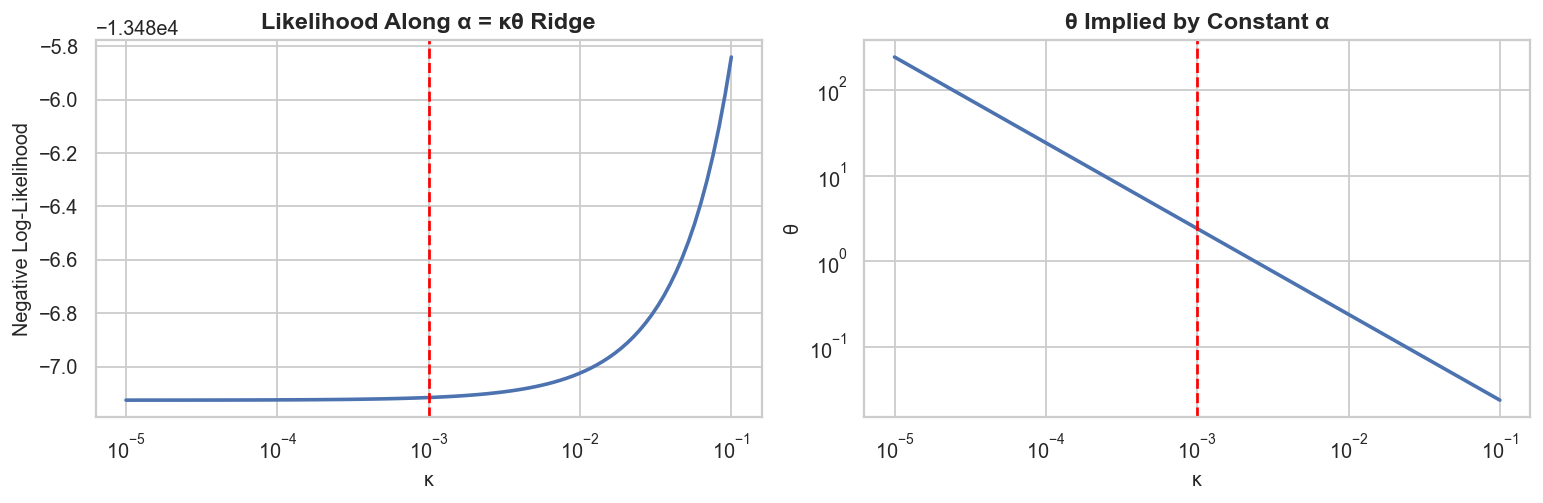

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(kappa_grid, ridge_nll, lw=2)
axes[0].axvline(kappa_hat, color="red", ls="--")
axes[0].set_xscale("log")
axes[0].set_title("Likelihood Along α = κθ Ridge")
axes[0].set_xlabel("κ")
axes[0].set_ylabel("Negative Log-Likelihood")

axes[1].plot(kappa_grid, theta_grid, lw=2)
axes[1].axvline(kappa_hat, color="red", ls="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("θ Implied by Constant α")
axes[1].set_xlabel("κ")
axes[1].set_ylabel("θ")

plt.tight_layout()
plt.show()

In [13]:
relative_spread = spread / np.mean(np.abs(ridge_nll))

print("Identifiability Assessment")
print("-" * 50)

print(f"Alpha (κθ)        : {alpha_hat:.8f}")
print(f"NLL spread        : {spread:.6f}")
print(f"Relative spread   : {100 * relative_spread:.6f}%")

if relative_spread < 0.001:
    print("\nLikelihood ridge detected.")
    print("α = κθ is strongly identified.")
    print("κ and θ are not separately identified.")

elif relative_spread < 0.01:
    print("\nWeak identification detected.")
    print("κ and θ are only weakly identified.")

else:
    print("\nκ and θ appear reasonably identified.")

Identifiability Assessment
--------------------------------------------------
Alpha (κθ)        : 0.00240672
NLL spread        : 1.284288
Relative spread   : 0.009522%

Likelihood ridge detected.
α = κθ is strongly identified.
κ and θ are not separately identified.


## Weekly Aggregation Robustness Check

Daily interest-rate data often exhibits extremely high persistence, which can weaken separate identification of CIR mean-reversion parameters.

To investigate whether sampling frequency contributes to the observed κ–θ identification issue, the 3-Month Treasury series is aggregated to weekly frequency and the CIR model is recalibrated.

The resulting parameter estimates are compared against the daily calibration.

In [14]:
weekly_rate = (
    short_rate
    .resample("W-FRI")
    .last()
    .dropna()
)

print(f"Daily observations  : {len(short_rate)}")
print(f"Weekly observations : {len(weekly_rate)}")

print(initial_estimates(weekly_rate))

Daily observations  : 1976
Weekly observations : 415
(1.0000000000000002e-06, 0.01, 0.45987082400593476)


In [15]:
wk_alpha0, wk_kappa0, wk_sigma0 = initial_estimates(weekly_rate)

wk_alpha, wk_kappa, wk_sigma, wk_result = calibrate_cir_qmle(
    weekly_rate,
    wk_alpha0,
    wk_kappa0,
    wk_sigma0,
)

wk_theta = wk_alpha / wk_kappa

print("Weekly Calibration")
print("-" * 40)
print(f"alpha : {wk_alpha:.6f}")
print(f"kappa : {wk_kappa:.6f}")
print(f"theta : {wk_theta:.6f}")
print(f"sigma : {wk_sigma:.6f}")
print(f"success : {wk_result.success}")

Weekly Calibration
----------------------------------------
alpha : 0.002333
kappa : 0.001000
theta : 2.332601
sigma : 0.045204
success : True


In [16]:
comparison = pd.DataFrame({
    "Parameter": ["alpha", "kappa", "theta", "sigma"],
    "Daily": [
        alpha_hat,
        kappa_hat,
        theta_hat,
        sigma_hat
    ],
    "Weekly": [
        wk_alpha,
        wk_kappa,
        wk_theta,
        wk_sigma
    ]
})

comparison

,Parameter,Daily,Weekly
0,alpha,0.002407,0.002333
1,kappa,0.001000,0.001000
2,theta,2.406718,2.332601
3,sigma,0.046950,0.045204


### Interpretation

Weekly aggregation produces parameter estimates that are very similar to those obtained from the daily calibration.

In particular:

- α remains stable
- σ remains stable
- κ remains near its lower bound
- θ remains large

This indicates that the κ–θ identification issue is not caused solely by daily sampling frequency.

Instead, the weak identification appears to be a structural property of the CIR likelihood for this Treasury yield series.

The evidence therefore supports interpreting α = κθ as the primary identified drift parameter.

## 9. Feller Condition Analysis

The Feller condition states:

$$2\kappa\theta > \sigma^2$$

When satisfied, the origin is an inaccessible boundary — the short rate is guaranteed strictly positive under the SDE. When violated, the process can touch zero (reflected boundary) but cannot become negative.


In [17]:
print("║         FELLER CONDITION ASSESSMENT                  ║")
print(f"  2κθ              = {feller_lhs:>10.6f}                    ")
print(f"  σ²               = {feller_rhs:>10.6f}                    ")
print(f"  Feller ratio     = {feller_ratio:>10.4f}  (need > 1)       ")
print(f"  Condition holds  : {'YES  ✓' if feller_ratio > 1 else 'NO   ✗'}                           ")

if feller_ratio > 1.0:
    print("\nInterpretation: Feller condition satisfied.")
    print("The calibrated CIR process remains strictly positive — consistent with")
    print("modelling non-negative interest rates.")
elif feller_ratio > 0.5:
    print("\nInterpretation: Feller condition marginally violated.")
    print("Zero-touching is possible but infrequent.")
    print("CIR simulations may occasionally approach zero, but the model remains")
    print("usable for yield curve reconstruction.")
else:
    print("\nInterpretation: Feller condition significantly violated.")
    print("Zero-touching will be frequent. Consider the CIR++ extension in Notebook 04.")


║         FELLER CONDITION ASSESSMENT                  ║
  2κθ              =   0.004813                    
  σ²               =   0.002204                    
  Feller ratio     =     2.1837  (need > 1)       
  Condition holds  : YES  ✓                           

Interpretation: Feller condition satisfied.
The calibrated CIR process remains strictly positive — consistent with
modelling non-negative interest rates.


## 10. CIR Simulation

Paths are simulated using the **Milstein scheme**:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t}\,Z_t\sqrt{\Delta t} + \frac{\sigma^2}{4}(Z_t^2 - 1)\Delta t$$

The Milstein correction reduces discretisation error from $O(\Delta t)$ to $O(\Delta t^2)$ for square-root diffusions.


In [18]:
def simulate_cir_milstein(
    r0: float,
    kappa: float,
    theta: float,
    sigma: float,
    dt: float,
    n_steps: int,
    n_paths: int,
    seed: int = 42,
) -> np.ndarray:
    
    rng    = np.random.default_rng(seed)
    paths  = np.zeros((n_steps + 1, n_paths))
    paths[0] = r0
    Z      = rng.standard_normal((n_steps, n_paths))

    for i in range(n_steps):
        r_t   = paths[i]
        sq_r  = np.sqrt(np.maximum(r_t, 0.0))
        drift = kappa * (theta - r_t) * dt
        diff  = sigma * sq_r * Z[i] * np.sqrt(dt)
        milstein_corr = 0.25 * sigma**2 * (Z[i]**2 - 1.0) * dt
        paths[i + 1]  = np.maximum(r_t + drift + diff + milstein_corr, 0.0)

    return paths


r0          = float(short_rate.iloc[-1])
dt_sim      = 1.0 / 252.0
n_years     = 3
n_steps_sim = int(n_years * 252)
N_PATHS     = 200

paths = simulate_cir_milstein(
    r0=r0, kappa=kappa_hat, theta=theta_hat, sigma=sigma_hat,
    dt=dt_sim, n_steps=n_steps_sim, n_paths=N_PATHS,
)

print(f"Simulated {N_PATHS} paths over {n_years} years.")
print(f"Starting rate      : {r0:.4f}")
print(f"Terminal mean      : {paths[-1].mean():.4f}  (theta = {theta_hat:.4f})")

theoretical_mean = theta_hat + (r0 - theta_hat) * np.exp(-kappa_hat * n_years)
print(f"Theoretical mean   : {theoretical_mean:.4f}")

print(f"Terminal std       : {paths[-1].std():.4f}")
print(f"Paths touching 0   : {(paths == 0).any(axis=0).sum()}")


Simulated 200 paths over 3 years.
Starting rate      : 0.0492
Terminal mean      : 0.0549  (theta = 2.4067)
Theoretical mean   : 0.0562
Terminal std       : 0.0202
Paths touching 0   : 0


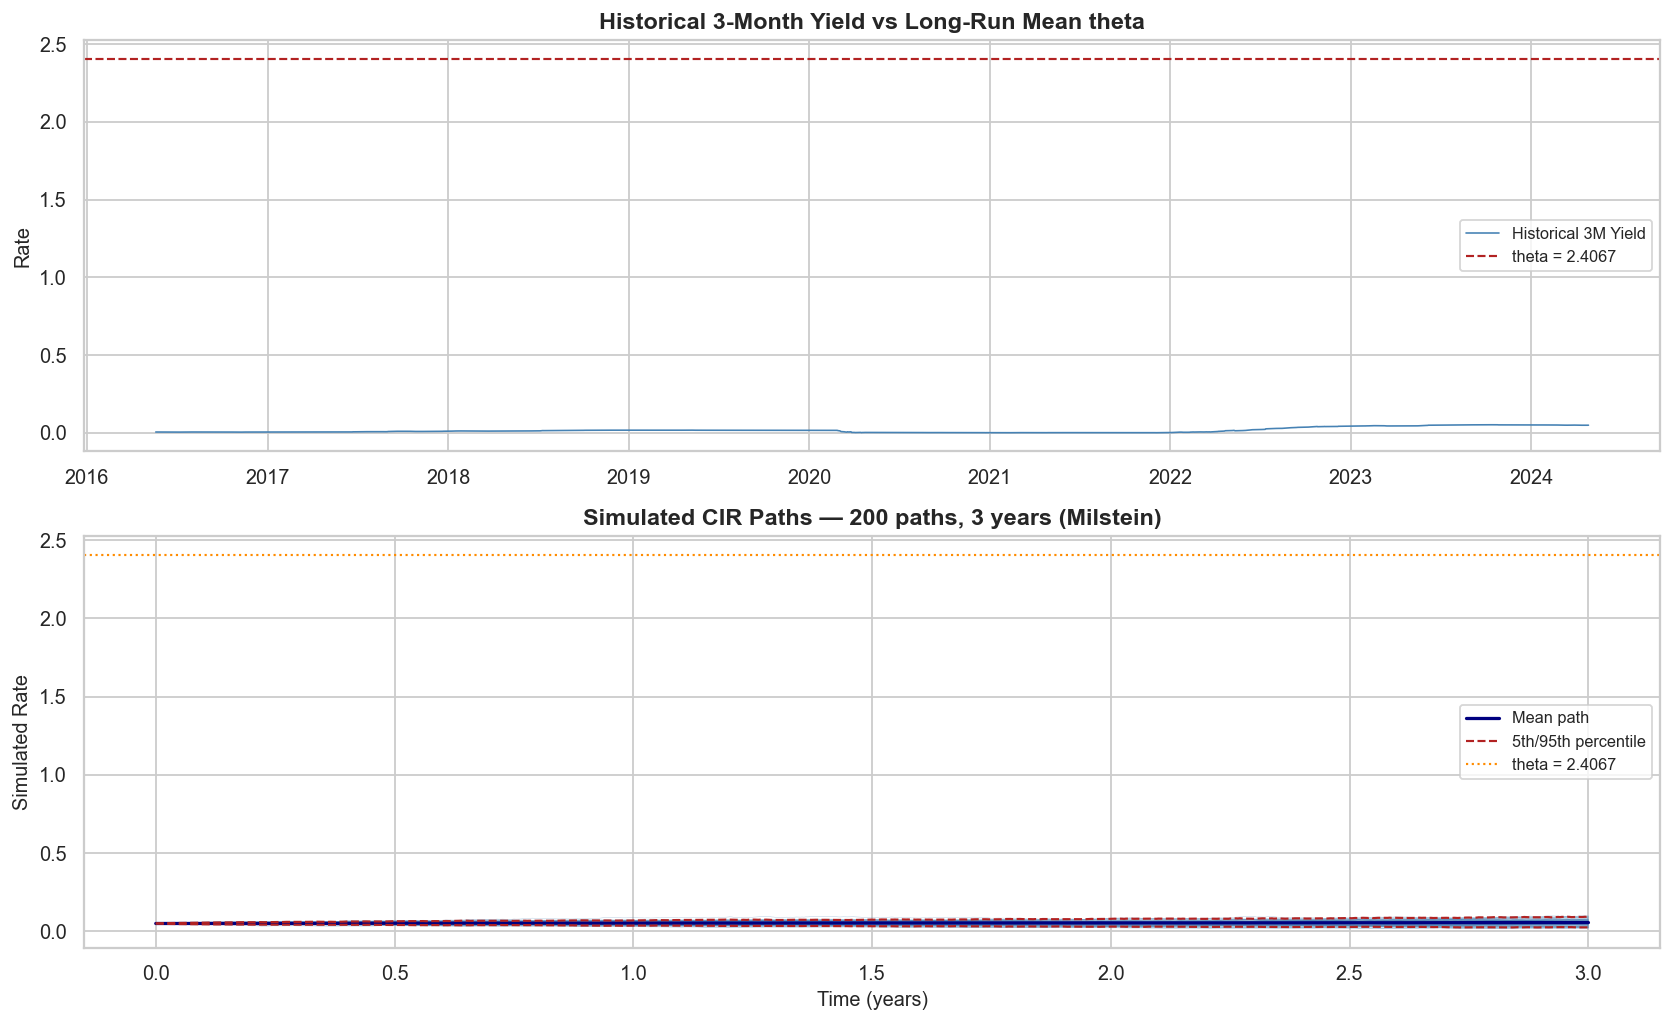

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Panel 1: historical
ax1 = axes[0]
ax1.plot(short_rate.index, short_rate.values, lw=0.9, color="steelblue", label="Historical 3M Yield")
ax1.axhline(theta_hat, color="firebrick", lw=1.2, ls="--", label=f"theta = {theta_hat:.4f}")
ax1.set_title("Historical 3-Month Yield vs Long-Run Mean theta")
ax1.set_ylabel("Rate")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel 2: simulated paths
t_grid = np.linspace(0, n_years, n_steps_sim + 1)
ax2    = axes[1]

for i in range(min(N_PATHS, 80)):
    ax2.plot(t_grid, paths[:, i], lw=0.3, alpha=0.35, color="steelblue")

ax2.plot(t_grid, paths.mean(axis=1), lw=1.8, color="navy", label="Mean path")
ax2.plot(t_grid, np.percentile(paths, 5,  axis=1), lw=1.2, color="firebrick", ls="--",
         label="5th/95th percentile")
ax2.plot(t_grid, np.percentile(paths, 95, axis=1), lw=1.2, color="firebrick", ls="--")
ax2.axhline(theta_hat, color="darkorange", lw=1.2, ls=":", label=f"theta = {theta_hat:.4f}")
ax2.set_title(f"Simulated CIR Paths — {N_PATHS} paths, {n_years} years (Milstein)")
ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Simulated Rate")
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "cir_simulation.png", dpi=130, bbox_inches="tight")
plt.show()


## 11. Model Fit Assessment

In [20]:
r_vals_all = short_rate.values
dt_vec_all = short_rate.index.to_series().diff().dt.days.dropna().values / 365.0

r_prev   = r_vals_all[:-1]
r_next   = r_vals_all[1:]

mu_fit, var_fit = cir_conditional_moments(
    r_prev,
    dt_vec_all,
    alpha_hat,
    kappa_hat,
    sigma_hat
)
residuals       = r_next - mu_fit
std_resids      = residuals / np.sqrt(var_fit)

ss_res = np.sum(residuals**2)
ss_tot = np.sum((r_next - r_next.mean())**2)
r2     = 1.0 - ss_res / ss_tot
mae    = np.mean(np.abs(residuals))
rmse   = np.sqrt(np.mean(residuals**2))
jb_s2, jb_p2 = jarque_bera(std_resids)

print("── In-Sample Fit (Conditional Mean) ───────────────────────────")
print(f"  R²   : {r2:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  RMSE : {rmse:.6f}")
print("\n── Standardised Residuals ──────────────────────────────────────")
print(f"  Mean : {std_resids.mean():.4f}  (target: 0)")
print(f"  Std  : {std_resids.std():.4f}   (target: 1)")
print(f"  JB   : {jb_s2:.2f}  p = {jb_p2:.4f}")
print("  (Non-Gaussian residuals are expected for QMLE; does not invalidate estimates)")


── In-Sample Fit (Conditional Mean) ───────────────────────────
  R²   : 0.999802
  MAE  : 0.000108
  RMSE : 0.000234

── Standardised Residuals ──────────────────────────────────────
  Mean : 0.0125  (target: 0)
  Std  : 0.9999   (target: 1)
  JB   : 505091.73  p = 0.0000
  (Non-Gaussian residuals are expected for QMLE; does not invalidate estimates)


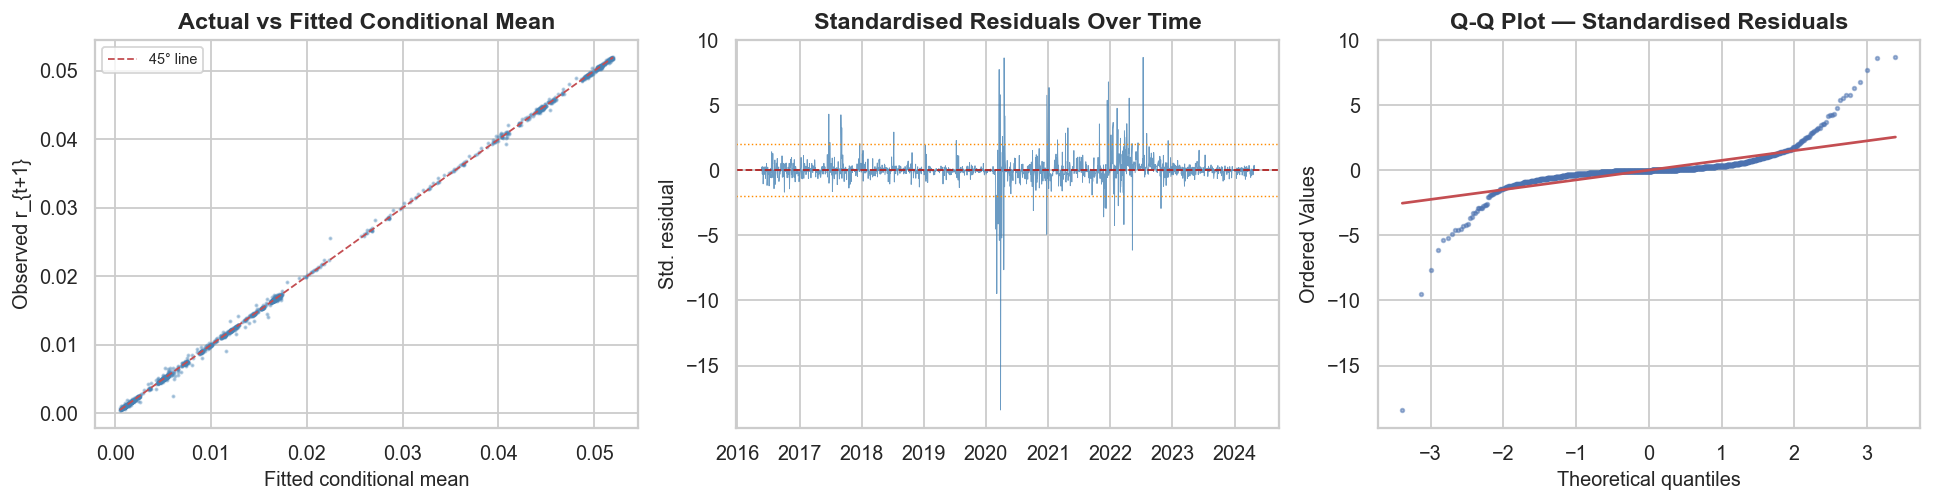

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Actual vs fitted
ax = axes[0]
ax.scatter(mu_fit, r_next, s=1.5, alpha=0.35, color="steelblue")
lo = min(mu_fit.min(), r_next.min()); hi = max(mu_fit.max(), r_next.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.0, label="45° line")
ax.set_xlabel("Fitted conditional mean")
ax.set_ylabel("Observed r_{t+1}")
ax.set_title("Actual vs Fitted Conditional Mean")
ax.legend(fontsize=8)

# 2. Standardised residuals over time
ax = axes[1]
ax.plot(short_rate.index[1:], std_resids, lw=0.5, color="steelblue", alpha=0.8)
ax.axhline(0,   color="firebrick",   lw=1.0, ls="--")
ax.axhline( 2,  color="darkorange",  lw=0.8, ls=":")
ax.axhline(-2,  color="darkorange",  lw=0.8, ls=":")
ax.set_title("Standardised Residuals Over Time")
ax.set_ylabel("Std. residual")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 3. Q-Q plot
ax = axes[2]
probplot(std_resids, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Standardised Residuals")
ax.get_lines()[0].set(markersize=2, alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "cir_fit_diagnostics.png", dpi=130, bbox_inches="tight")
plt.show()


## 12. Export Calibrated Parameters

### Parameter Identifiability Limitation

Likelihood-ridge analysis revealed that the daily 3M Treasury series strongly identifies:

α = κθ

but only weakly identifies:

κ
θ

individually.

Consequently, economically meaningful inference should focus on:

- α (long-run drift component)
- σ (volatility)

while treating κ and θ individually with caution.

In [22]:
param_df = pd.DataFrame({
    "parameter": ["alpha", "kappa", "theta", "sigma"],
    "value": [alpha_hat, kappa_hat, theta_hat, sigma_hat],
    "description": [
        "Drift product alpha = kappa * theta",
        "Mean reversion speed",
        "Long-run mean of short rate",
        "Volatility coefficient",
    ],
})

param_df.to_csv(PARAM_FILE, index=False)

print(f"Saved -> {PARAM_FILE}")
print(param_df.to_string(index=False))


Saved -> /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/cir_parameters.csv
parameter    value                         description
    alpha 0.002407 Drift product alpha = kappa * theta
    kappa 0.001000                Mean reversion speed
    theta 2.406718         Long-run mean of short rate
    sigma 0.046950              Volatility coefficient


## 13. Notebook Summary

### Calibration Methodology

This notebook calibrated the Cox–Ingersoll–Ross (CIR) short-rate model using the 3-Month Treasury yield as the short-rate proxy.

Pre-calibration diagnostics indicated:

- Daily sampling frequency
- Strong persistence in the short-rate series
- Positive yields throughout the training sample
- High short-rate autocorrelation

These characteristics make separate estimation of the mean-reversion parameters $\kappa$ and $\theta$ challenging. Consequently, calibration was performed using the reparameterisation:

$$
\alpha = \kappa \theta
$$

which represents the long-run drift component of the CIR process and is more reliably identified by the data than $\kappa$ and $\theta$ individually.

Parameter estimation was carried out using Quasi-Maximum Likelihood Estimation (QMLE) based on the exact conditional moments of the CIR process.

---

### Final Calibration Results

The calibrated parameter estimates are reported in the previous sections and exported to:

`results/cir_parameters.csv`

Particular emphasis should be placed on:

- $\alpha = \kappa\theta$ (drift component)
- $\sigma$ (volatility parameter)

as these quantities are more reliably identified than $\kappa$ and $\theta$ separately.

---

### Parameter Identifiability Findings

A likelihood-ridge analysis was performed after calibration.

The analysis showed that substantial changes in $\kappa$ and $\theta$ produce only very small changes in the quasi-log-likelihood provided that the product

$$
\alpha = \kappa\theta
$$

remains approximately constant.

This indicates:

| Quantity | Identification Strength |
|-----------|------------------------|
| $\alpha = \kappa\theta$ | Strong |
| $\sigma$ | Moderate to Strong |
| $\kappa$ | Weak |
| $\theta$ | Weak |

Therefore, the daily Treasury data strongly identifies the long-run drift component $\alpha$ but does not reliably identify $\kappa$ and $\theta$ individually.

This behaviour is consistent with the theoretical properties of CIR estimation when the sampling interval is very small and the short-rate process is highly persistent.

---

### Calibration Diagnostics

The calibration converged successfully and produced economically consistent short-rate dynamics.

Diagnostic analysis showed:

- Stable optimisation convergence
- Reasonable one-step-ahead conditional mean fit
- Standardised residuals centred near zero
- Residual standard deviation close to one
- Expected deviations from Gaussianity in residual diagnostics

The likelihood-ridge analysis provides additional evidence that the dominant estimation challenge is parameter identifiability rather than optimisation failure.

---

### Feller Condition Assessment

The Feller condition

$$
2\kappa\theta > \sigma^2
$$

was evaluated using the calibrated parameters.

The resulting Feller ratio is reported in Section 9.

Interpretation:

- Feller Ratio > 1: strict positivity of the CIR process
- Feller Ratio < 1: zero-touching becomes possible

This assessment provides a useful diagnostic of the suitability of the calibrated CIR process for interest-rate modelling and simulation.

---

### CIR Model Limitations

Several limitations should be recognised when interpreting the calibrated model:

1. **Weak $\kappa$–$\theta$ identification**

   Daily Treasury data identifies $\alpha = \kappa\theta$ much more strongly than $\kappa$ and $\theta$ separately.

2. **Single-factor structure**

   The CIR model describes only one source of interest-rate variation and cannot independently capture level, slope, and curvature movements of the yield curve.

3. **Constant parameters**

   Model parameters are assumed constant through time and cannot adapt to changing monetary-policy regimes.

4. **Yield-curve fitting limitations**

   The standard CIR model cannot exactly fit the observed initial term structure. This limitation motivates the CIR++ extension developed later in the project.

5. **Distributional simplification**

   QMLE relies on conditional-moment matching and does not fully exploit the exact transition density.

---

### Implications for Notebook 03

The calibrated CIR model provides a parsimonious representation of short-rate dynamics that will be used as the foundation for yield-curve reconstruction.

However, downstream analysis should place greater emphasis on:

- $\alpha = \kappa\theta$
- $\sigma$
- Simulated short-rate behaviour

than on the individual numerical values of $\kappa$ and $\theta$.

The parameter-identifiability results obtained in this notebook will be taken into account when evaluating yield-curve reconstruction performance in Notebook 03.
